# Inference Explorer — understanding `frames.py` & the context trade space

Two goals:

1. **Build the big ledger DataFrame one stage at a time**, so you can see exactly
   what each `frames.py` function adds and *why* it's factored that way.
2. **Explore the trade space:** how much transcript do we hand the LLM per call —
   one turn, a window, or the whole conversation? What does each choice cost, and
   how well does it work?

The ledger is assembled by three small, single-purpose functions, each adding a
group of columns:

```
raw pipeline output ─┬─ build_ledger()          → trace + inference columns
                     ├─ attach_dependencies()   → cross-artifact links
                     └─ attach_gold()           → evaluation vs. ground truth
```

They're kept separate on purpose: derivation (what the model produced), relation
(how artifacts relate to each other), and evaluation (how we grade it) are
independent concerns — you can run the first without a gold file, add the second
without re-deriving, and swap the third's matcher without touching either.

## 0 · Setup

In [1]:
import sys, json, importlib
from pathlib import Path
import pandas as pd

_here = Path.cwd()
REPO = next(p for p in (_here, *_here.parents) if (p / "research" / "corpus").exists())
HARNESS = str((REPO / "research" / "harness").resolve())
if HARNESS not in sys.path:
    sys.path.insert(0, HARNESS)

pd.set_option("display.max_colwidth", 60)
pd.set_option("display.width", 200)

# --- knobs -----------------------------------------------------------------
CASE = "warehouse-modernization"   # the mock-tuned case: nonzero recall + populated gold columns
PROVIDER = "mock"            # "mock" (no keys) | "openai_compatible" (needs LLM_API_KEY)
STRATEGY = "window"         # strategy for the walkthrough (the sweep below tries all three)
WINDOW_SECONDS = 30         # size of a "window" chunk (small, so window is distinct from full here)
WORDS_PER_MINUTE = 150      # realistic clock so window ≠ full on short transcripts
MATCHER = "lexical"
THRESHOLD = 0.30

CORPUS = REPO / "research" / "corpus"
print(f"case={CASE!r} provider={PROVIDER!r} walkthrough strategy={STRATEGY!r}")

case='warehouse-modernization' provider='mock' walkthrough strategy='window'


### A reusable one-case runner

Everything below calls this. It drives the **real** pipeline (the same code the
app runs) and hands back the raw objects `frames.py` consumes: ordered
`segments`, `derived` artifacts, their `evidence` links, and the `gold` labels.

In [2]:
import ingest as ingest_mod, match as match_mod, score as score_mod, frames
from _bootstrap import make_context, provider_available, build_embedder
from app.services.context_strategy import get_context_strategy
importlib.reload(frames)

ok, why = provider_available(PROVIDER)
assert ok, f"provider {PROVIDER!r} unavailable: {why}"


def run_case(provider, strategy, *, case=CASE, window_seconds=WINDOW_SECONDS, wpm=WORDS_PER_MINUTE):
    """Drive the pipeline once; return (segments, derived, evidence, gold)."""
    case_dir = CORPUS / case
    transcript = ingest_mod.load_transcript(case_dir / "transcript.json")
    gold_path = case_dir / "gold.json"
    gold = json.loads(gold_path.read_text())["gold_artifacts"] if gold_path.exists() else []
    ctx = make_context(provider, strategy, window_seconds=window_seconds)
    try:
        segments = ingest_mod.ingest(ctx, transcript, words_per_minute=wpm)
        ctx.analysis.analyze_session(ctx.session_id)
        derived = ctx.artifacts.list_for_session(ctx.session_id)
        evidence = {a.id: ctx.artifacts.evidence_for(a.id) for a in derived}
    finally:
        ctx.close()
    return segments, derived, evidence, gold


segments, derived, evidence, gold = run_case(PROVIDER, STRATEGY)
print(f"{len(segments)} segments · {len(derived)} artifacts · "
      f"{sum(len(v) for v in evidence.values())} evidence links · {len(gold)} gold labels")

8 segments · 5 artifacts · 5 evidence links · 11 gold labels


## 1 · The raw inputs (before any DataFrame)

`frames.py` never derives anything — it *reshapes* these three objects. Look at
one derived artifact and its evidence so you can see what a ledger row is built
from:

- a **`DiscoveryArtifact`** — type, title, statement, confidence, lifecycle
- its **`EvidenceLink`s** — which segment, the quoted span, the relationship

The join key throughout is `segments[i]` == turn `i`.

In [3]:
a = derived[0]
print("ARTIFACT")
for f in ["id", "artifact_type", "title", "statement", "confidence",
          "derivation_method", "validation_state", "status"]:
    print(f"  {f:18} {getattr(a, f)}")
print("\nEVIDENCE LINKS")
for l in evidence[a.id]:
    print(f"  segment={l.transcript_segment_id[:8]}  rel={l.relationship.value:12} "
          f"conf={l.confidence}  quote={l.quoted_text!r}")

ARTIFACT
  id                 3e1632f5-dfef-472d-8027-a970a4b6c52a
  artifact_type      ArtifactType.STAKEHOLDER_NEED
  title              Timely operational visibility
  statement          Stakeholders need timely, real-time visibility into operational status.
  confidence         0.8
  derivation_method  DerivationMethod.KEYWORD_HEURISTIC
  validation_state   ValidationState.INFERRED
  status             ArtifactStatus.CANDIDATE

EVIDENCE LINKS
  segment=5ab08831  rel=supporting   conf=0.8  quote='real-time view'


## 2 · Stage A — `build_ledger()`  → trace + inference columns

`build_ledger` walks each artifact, finds its **strongest** evidence link
(`max` by confidence), and resolves that link back through `segments` to a
turn's time / speaker / text. So one call fills two conceptual groups at once:

- **inference** — `artifact_type`, `title`, `statement`, `confidence`,
  `derivation_method`, `validation_state`, `status`
- **trace** — `segment_seq`, `start_time`, `end_time`, `speaker`,
  `evidence_quote`, `evidence_relationship`, `segment_text`

*Why one function?* Every artifact has exactly one "where did this come from"
answer, so trace and inference are the same row — splitting them would just force
a self-join. The `depends_on` / gold columns are left empty here (filled later).

In [4]:
ledger = frames.build_ledger(
    case=CASE, provider=PROVIDER, strategy=STRATEGY,
    derived=derived, evidence_by_artifact=evidence, segments=segments,
)
print("shape after build_ledger:", ledger.shape)

print("\n— inference group —")
display(ledger[["artifact_type", "title", "confidence", "derivation_method", "validation_state"]])
print("— trace group —")
display(ledger[["segment_seq", "start_time", "speaker_name", "evidence_relationship", "evidence_quote"]])

shape after build_ledger: (5, 26)

— inference group —


,artifact_type,title,confidence,derivation_method,validation_state
0,stakeholder_need,Timely operational visibility,0.80,keyword_heuristic,inferred
1,requirement,Quantified freshness target,0.92,keyword_heuristic,inferred
2,constraint,System retention constraint,0.86,keyword_heuristic,inferred
3,constraint,Existing field hardware,0.76,keyword_heuristic,inferred
4,constraint,Deployment timeline constraint,0.77,keyword_heuristic,inferred


— trace group —


,segment_seq,start_time,speaker_name,evidence_relationship,evidence_quote
0,1,6.5,Customer,supporting,real-time view
1,3,24.3,Customer,direct,within 30 seconds
2,4,31.6,Customer,direct,cannot replace
3,4,31.6,Customer,direct,rugged tablet
4,6,46.6,Customer,direct,go-live


## 3 · Stage B — `attach_dependencies()`  → cross-artifact links

`detect_dependencies` compares every *pair* of artifacts and labels a link
`reinforcement` (same type + high statement overlap — the same idea corroborated),
`conflict` (supersession or a contradicting evidence relationship), or `related`
(shared segment / mid overlap). `attach_dependencies` folds those edges back onto
the ledger as `depends_on` (neighbor ids) and `dependency_kind` (worst-case link).

*Why a separate function?* Dependencies are a property of the **set**, not of any
single artifact — you can't know them while building a row. Keeping it separate
also means you can swap this transparent lexical v1 for a model-based conflict
detector without touching `build_ledger`.

In [5]:
deps = frames.detect_dependencies(derived=derived, evidence_by_artifact=evidence)
print("edges found:")
display(deps[["kind", "score", "basis", "source_title", "target_title"]])

ledger = frames.attach_dependencies(ledger, deps)
print("columns added: depends_on, dependency_kind")
display(ledger[["title", "artifact_type", "dependency_kind", "depends_on"]])

edges found:


,kind,score,basis,source_title,target_title
0,related,0.19,shared_segment,System retention constraint,Existing field hardware


columns added: depends_on, dependency_kind


,title,artifact_type,dependency_kind,depends_on
0,Timely operational visibility,stakeholder_need,NaN,[]
1,Quantified freshness target,requirement,NaN,[]
2,System retention constraint,constraint,related,[80f07989-c6ab-42b3-a9f6-1f0ea957addc]
3,Existing field hardware,constraint,related,[2b18a1b5-b1cf-4d24-abe0-90b6cdd3d3a9]
4,Deployment timeline constraint,constraint,NaN,[]


## 4 · Stage C — `attach_gold()`  → evaluation vs. ground truth

Only runs when the case has a `gold.json`. A **matcher** aligns each derived
artifact to at most one gold label (greedy, by similarity ≥ threshold); then
`attach_gold` records `matched_gold_id`, the `gold_type`, and whether the
inferred type was `correct_type`.

*Why separate — and why a pluggable matcher?* Grading is a different question from
producing, and *how* you decide two statements "match" (lexical overlap vs.
embedding similarity) is itself a research knob. Isolating it lets you re-grade a
frozen derivation under different matchers.

In [6]:
if gold:
    matcher = match_mod.get_matcher(MATCHER, embedder=build_embedder() if MATCHER == "embedding" else None)
    pairs = matcher.match(derived, gold, evidence, threshold=THRESHOLD)
    ledger = frames.attach_gold(ledger, derived=derived, gold=gold, pairs=pairs, evidence_by_artifact=evidence)
    print(f"{len(pairs)}/{len(derived)} derived artifacts matched a gold label")
    display(ledger[["artifact_type", "matched_gold_id", "gold_type", "correct_type", "statement"]])
else:
    print("no gold.json for this case — evaluation columns stay empty")

3/5 derived artifacts matched a gold label


,artifact_type,matched_gold_id,gold_type,correct_type,statement
0,stakeholder_need,NEED-001,stakeholder_need,True,"Stakeholders need timely, real-time visibility into oper..."
1,requirement,REQ-002,requirement,True,The solution shall refresh information within within 30 ...
2,constraint,NaN,NaN,NaN,The solution shall integrate with the existing system wi...
3,constraint,NaN,NaN,NaN,The solution shall operate on the existing field devices...
4,constraint,CON-008,constraint,True,The solution shall be delivered within the stated deploy...


### The finished ledger

All 26 columns, assembled in three stages. This is the "large DataFrame.

In [7]:
print("final shape:", ledger.shape)
print("columns:", list(ledger.columns))
ledger

final shape: (5, 26)
columns: ['case', 'provider', 'strategy', 'artifact_id', 'artifact_type', 'title', 'statement', 'confidence', 'derivation_method', 'validation_state', 'status', 'evidence_count', 'segment_seq', 'start_time', 'end_time', 'speaker', 'speaker_name', 'evidence_quote', 'evidence_relationship', 'segment_text', 'depends_on', 'dependency_kind', 'matched_gold_id', 'gold_type', 'correct_type', 'quote_grounded']


,case,provider,strategy,artifact_id,artifact_type,title,statement,confidence,derivation_method,validation_state,...,speaker_name,evidence_quote,evidence_relationship,segment_text,depends_on,dependency_kind,matched_gold_id,gold_type,correct_type,quote_grounded
0,warehouse-modernization,mock,window,3e1632f5-dfef-472d-8027-a970a4b6c52a,stakeholder_need,Timely operational visibility,"Stakeholders need timely, real-time visibility into oper...",0.80,keyword_heuristic,inferred,...,Customer,real-time view,supporting,Our supervisors do not have a reliable real-time view of...,[],NaN,NEED-001,stakeholder_need,True,None
1,warehouse-modernization,mock,window,e17e5fa3-2e76-4256-aa00-2285b477b01b,requirement,Quantified freshness target,The solution shall refresh information within within 30 ...,0.92,keyword_heuristic,inferred,...,Customer,within 30 seconds,direct,Ideally within 30 seconds. Anything over a couple of min...,[],NaN,REQ-002,requirement,True,None
2,warehouse-modernization,mock,window,2b18a1b5-b1cf-4d24-abe0-90b6cdd3d3a9,constraint,System retention constraint,The solution shall integrate with the existing system wi...,0.86,keyword_heuristic,inferred,...,Customer,cannot replace,direct,We also need it to work on the rugged tablets the floor ...,[80f07989-c6ab-42b3-a9f6-1f0ea957addc],related,NaN,NaN,NaN,None
3,warehouse-modernization,mock,window,80f07989-c6ab-42b3-a9f6-1f0ea957addc,constraint,Existing field hardware,The solution shall operate on the existing field devices...,0.76,keyword_heuristic,inferred,...,Customer,rugged tablet,direct,We also need it to work on the rugged tablets the floor ...,[2b18a1b5-b1cf-4d24-abe0-90b6cdd3d3a9],related,NaN,NaN,NaN,None
4,warehouse-modernization,mock,window,a3f5d160-1ee9-4d26-9c93-379abeb0afe9,constraint,Deployment timeline constraint,The solution shall be delivered within the stated deploy...,0.77,keyword_heuristic,inferred,...,Customer,go-live,direct,"It has to be live before our peak season, so we need go-...",[],NaN,CON-008,constraint,True,None


## 5 · The trade space — how much context per call?

This is the *why* behind the `ContextStrategy` seam. Each strategy groups the
transcript into the chunks (`AnalysisUnit`s) the model sees:

| strategy | context per call | cost | cross-turn reasoning | incremental? |
|----------|------------------|------|----------------------|--------------|
| `segment`| one turn         | cheapest | none | yes (per utterance) |
| `window` | ~N seconds       | bounded | within the window | yes (per window) |
| `full`   | whole conversation | grows with session | best | no (re-run each time) |

We sweep all three and measure **cost** (calls, tokens/chunk — the context-window
constraint) against **quality** (recall / precision / type-accuracy / grounding
vs. gold).

In [8]:
rows = []
for strat in ["segment", "window", "full"]:
    segs, der, ev, g = run_case(PROVIDER, strat)
    chunks = frames.build_context_chunks(segs, get_context_strategy(strat, window_seconds=WINDOW_SECONDS))
    cov = frames.build_segment_coverage(derived=der, evidence_by_artifact=ev, segments=segs)
    m = match_mod.get_matcher(MATCHER, embedder=build_embedder() if MATCHER == "embedding" else None)
    pairs = m.match(der, g, ev, threshold=THRESHOLD) if g else []
    s = score_mod.score(der, ev, g, pairs, segs) if g else {"recovery": {}, "typing": {}, "traceability": {}}
    rows.append({
        "strategy": strat,
        # cost (independent of provider — this is the context-window math)
        "llm_calls": len(chunks),
        "max_tokens/call": int(chunks["context_tokens"].max()),
        "total_tokens": int(chunks["context_tokens"].sum()),
        # yield + quality
        "artifacts": len(der),
        "coverage%": round(100 * cov["inferred"].mean(), 0),
        "recall": s["recovery"].get("recall"),
        "precision": s["recovery"].get("precision"),
        "type_acc": s["typing"].get("type_accuracy"),
        "quote_grounded": s["traceability"].get("quote_grounded"),
    })

trade = pd.DataFrame(rows).set_index("strategy")
trade

,llm_calls,max_tokens/call,total_tokens,artifacts,coverage%,recall,precision,type_acc,quote_grounded
strategy,,,,,,,,,
segment,8,44,240,5,50.0,0.273,0.6,1.0,1.0
window,2,125,239,5,50.0,0.273,0.6,1.0,1.0
full,1,239,239,5,50.0,0.273,0.6,1.0,1.0


### Read the sweep

Two things to notice, and one caveat that is itself the lesson:

In [9]:
note = f"""
COST scales exactly as the table above shows, for ANY provider:
  segment -> many small calls   ({trade.loc['segment','llm_calls']} calls, {trade.loc['segment','max_tokens/call']} tok max)
  window  -> a few medium calls ({trade.loc['window','llm_calls']} calls, {trade.loc['window','max_tokens/call']} tok max)
  full    -> one big call        ({trade.loc['full','llm_calls']} call,  {trade.loc['full','max_tokens/call']} tok max)
That max-tokens/call column is what must stay under the model's context window.

QUALITY (recall/precision/type_acc) is FLAT across strategies here — because the
mock provider reads one segment at a time and cannot use extra context (see
research/README baseline). So with the mock, more context = more cost, no gain.

That flatness is the measuring stick: plug in a real LLM (PROVIDER=
'openai_compatible') that reasons over the whole unit, re-run this cell, and the
quality columns should rise from segment -> window -> full while cost rises too.
The trade space only becomes a real trade-off with a context-using provider.
"""
print(note)


COST scales exactly as the table above shows, for ANY provider:
  segment -> many small calls   (8 calls, 44 tok max)
  window  -> a few medium calls (2 calls, 125 tok max)
  full    -> one big call        (1 call,  239 tok max)
That max-tokens/call column is what must stay under the model's context window.

QUALITY (recall/precision/type_acc) is FLAT across strategies here — because the
mock provider reads one segment at a time and cannot use extra context (see
research/README baseline). So with the mock, more context = more cost, no gain.

That flatness is the measuring stick: plug in a real LLM (PROVIDER=
'openai_compatible') that reasons over the whole unit, re-run this cell, and the
quality columns should rise from segment -> window -> full while cost rises too.
The trade space only becomes a real trade-off with a context-using provider.



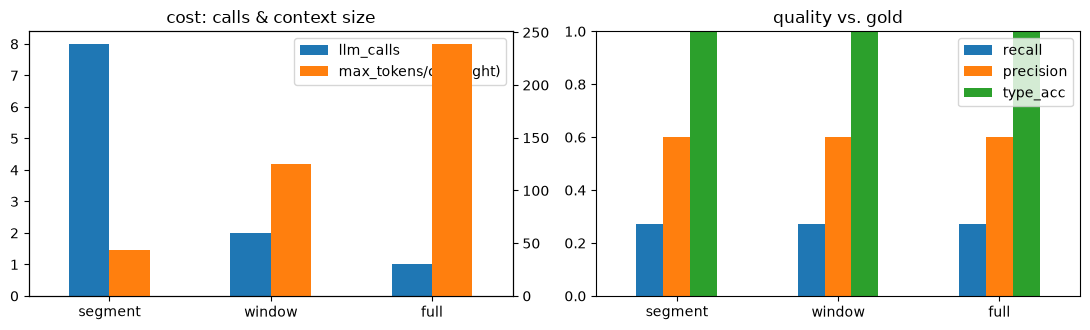

In [10]:
# cost vs. quality, side by side
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.4))
trade[["llm_calls", "max_tokens/call"]].plot(kind="bar", ax=ax1, rot=0,
                                             secondary_y="max_tokens/call")
ax1.set_title("cost: calls & context size"); ax1.set_xlabel("")
qcols = [c for c in ["recall", "precision", "type_acc"] if trade[c].notna().any()]
(trade[qcols] if qcols else trade[["coverage%"]]).plot(kind="bar", ax=ax2, rot=0)
ax2.set_ylim(0, 1 if qcols else None)
ax2.set_title("quality vs. gold" if qcols else "coverage%"); ax2.set_xlabel("")
plt.tight_layout(); plt.show()

## 6 · Visualize the derivation (walkthrough strategy)

Timeline of what was inferred from where, and the dependency graph.

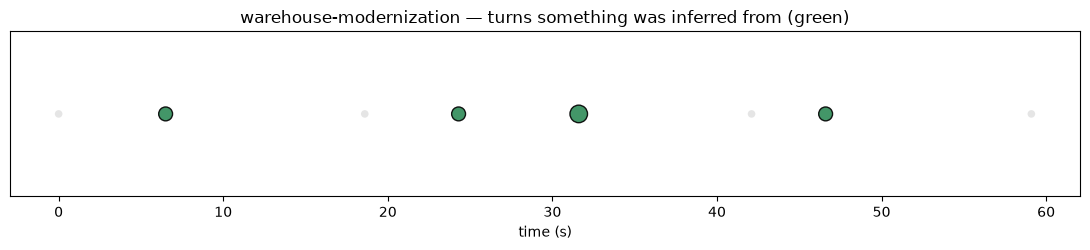

In [11]:
cov = frames.build_segment_coverage(derived=derived, evidence_by_artifact=evidence,
                                    segments=segments, context_strategy=get_context_strategy(STRATEGY, window_seconds=WINDOW_SECONDS))
fig, ax = plt.subplots(figsize=(11, 2.6))
for inferred in (False, True):
    sub = cov[cov["inferred"] == inferred]
    ax.scatter(sub["start_time"], [1]*len(sub),
               s=[40 + 60*n for n in sub["artifact_count"]] if inferred else 30,
               c="#2E8B57" if inferred else "#CCCCCC",
               edgecolors="black" if inferred else "none",
               alpha=0.9 if inferred else 0.5, zorder=3 if inferred else 2)
ax.set_yticks([]); ax.set_xlabel("time (s)")
ax.set_title(f"{CASE} — turns something was inferred from (green)")
plt.tight_layout(); plt.show()

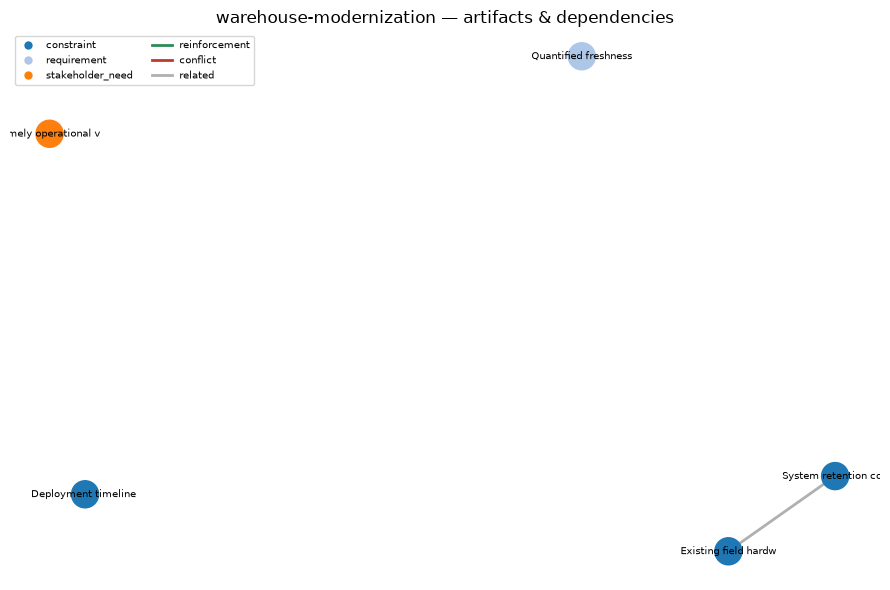

In [12]:
import networkx as nx
if len(deps):
    G = nx.Graph()
    for _, r in ledger.iterrows():
        G.add_node(r.artifact_id, type=r.artifact_type)
    ec = {"reinforcement": "#2E8B57", "conflict": "#C0392B", "related": "#B0B0B0"}
    for _, e in deps.iterrows():
        G.add_edge(e.source_id, e.target_id, color=ec.get(e.kind, "#B0B0B0"))
    types = sorted({d["type"] for _, d in G.nodes(data=True)})
    tcol = {t: c for t, c in zip(types, plt.cm.tab20.colors)}
    pos = nx.spring_layout(G, seed=7, k=0.9)
    fig, ax = plt.subplots(figsize=(9, 6))
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color=[G[u][v]["color"] for u, v in G.edges()], width=2)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=380, node_color=[tcol[G.nodes[n]["type"]] for n in G.nodes()])
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=7,
        labels={r.artifact_id: (r.title[:20] if r.title else r.artifact_type) for _, r in ledger.iterrows()})
    handles = ([plt.Line2D([], [], marker="o", ls="", mfc=tcol[t], mec="none", label=t) for t in types]
               + [plt.Line2D([], [], color=ec[k], lw=2, label=k) for k in ec])
    ax.legend(handles=handles, loc="upper left", fontsize=7, ncol=2); ax.set_axis_off()
    ax.set_title(f"{CASE} — artifacts & dependencies")
    plt.tight_layout(); plt.show()
else:
    print("no dependency edges for this run")

## Takeaways

- The ledger is three composable stages — **produce** (`build_ledger`), **relate**
  (`attach_dependencies`), **grade** (`attach_gold`) — so each concern evolves
  independently and works with or without a gold file.
- The context strategy is a **cost/quality dial**. Cost (calls × tokens-per-call)
  is fixed by math and must respect the model's context window; quality only moves
  when the provider actually *uses* the extra context.
- Swap `PROVIDER = "openai_compatible"` (set `LLM_API_KEY` / `LLM_API_BASE` /
  `LLM_MODEL`) and re-run §5 to turn the flat quality columns into a real curve —
  that's the experiment this notebook exists to make easy.